
OPAL vs TraceWin - sigma_x
  mean relative error       =  1.7567 %
  RMS relative error        =  11.5463 %

OPAL vs TraceWin - sigma_y
  mean relative error       =  1.0123 %
  RMS relative error        =  6.8412 %

OPAL vs TraceWin - transmission
  mean relative error       =  2.2251 %
  RMS relative error        =  3.0436 %

RF-Track vs TraceWin - sigma_x
  mean relative error       = -1.0738 %
  RMS relative error        =  5.4169 %

RF-Track vs TraceWin - sigma_y
  mean relative error       = -0.0289 %
  RMS relative error        =  3.8692 %

RF-Track vs TraceWin - transmission
  mean relative error       = -0.0631 %
  RMS relative error        =  0.2012 %


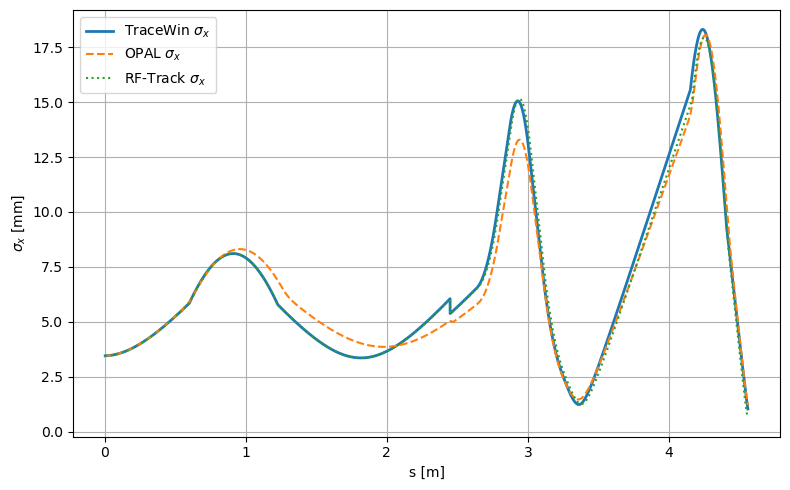

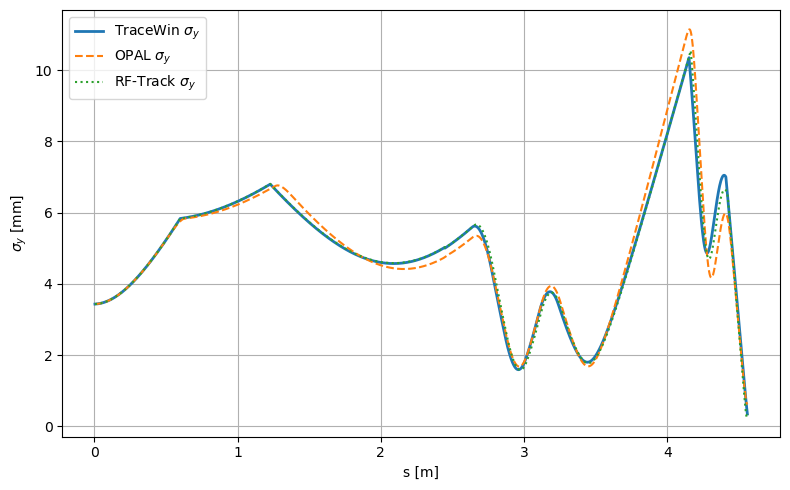

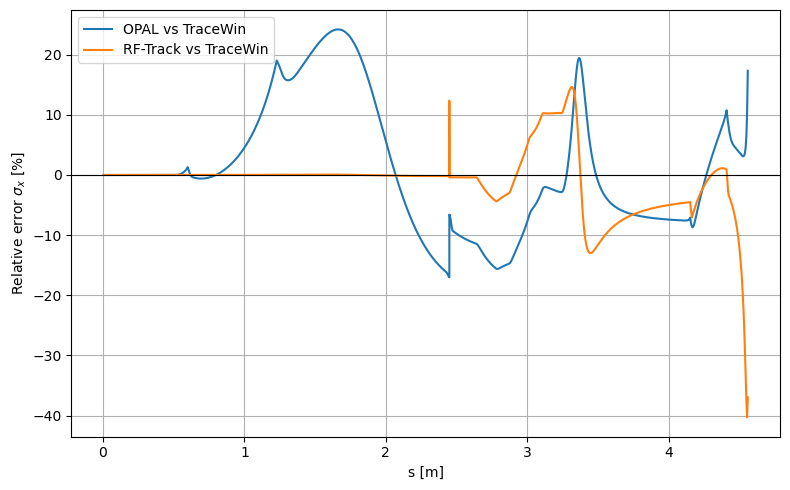

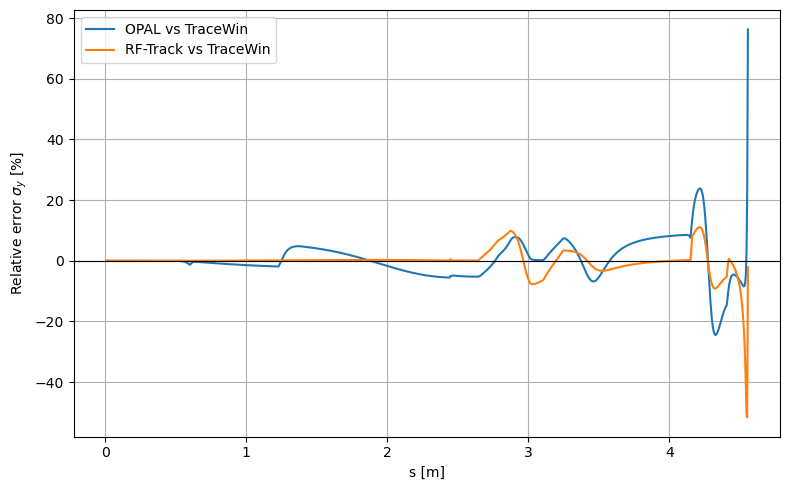

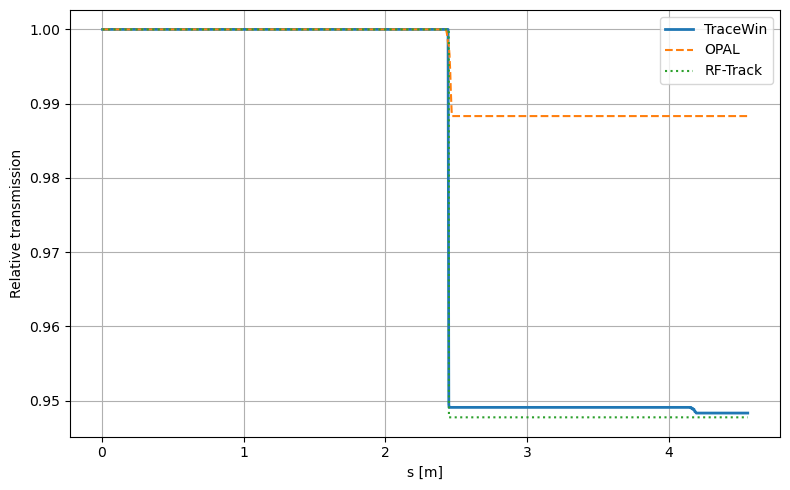

In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

root = Path.cwd()

# Load data from OPAL, RF-Track, and TraceWin
opal_lebt = np.loadtxt(root / "opal" / "lebt.stat", skiprows=303)

s_opal = opal_lebt[:, 1]
rms_x_opal = opal_lebt[:, 5] * 1e3   # m -> mm
rms_y_opal = opal_lebt[:, 6] * 1e3   # m -> mm
N_opal = opal_lebt[:, 2]

rftrack_lebt = np.loadtxt(root / "rftrack" / "rftrack_lebt_transport.txt", skiprows=1)

s_rf = rftrack_lebt[:, 0]
rms_x_rf = rftrack_lebt[:, 1]
rms_y_rf = rftrack_lebt[:, 2]
N_rf = rftrack_lebt[:, 3]

tracewin_lebt_x = np.loadtxt(root / "inputs" / "Chart_rmssizeX(mm).txt", skiprows=1)
tracewin_lebt_y = np.loadtxt(root / "inputs" / "Chart_rmssizeY(mm).txt", skiprows=1)
tracewin_trans = np.loadtxt(root / "inputs" / "Chart_Transmission(%).txt", skiprows=1)

s_tracewin_x = tracewin_lebt_x[:, 0]
s_tracewin_y = tracewin_lebt_y[:, 0]
s_tracewin_N = tracewin_trans[:, 0]

rms_x_tracewin = tracewin_lebt_x[:, 1]
rms_y_tracewin = tracewin_lebt_y[:, 1]
N_tracewin = tracewin_trans[:, 1]   # usually in %

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def sort_by_s(s, y):
    idx = np.argsort(s)
    return s[idx], y[idx]

def relative_error_percent(code, ref, eps=1e-12):
    return 100 * (code - ref) / (ref + eps)

def print_stats(name, err):
    print(f"\n{name}")
    print(f"  mean relative error       = {np.mean(err): .4f} %")
    print(f"  RMS relative error        = {np.sqrt(np.mean(err**2)): .4f} %")

# sort by s 
s_opal, rms_x_opal = sort_by_s(s_opal, rms_x_opal)
_, rms_y_opal = sort_by_s(s_opal, rms_y_opal)
_, N_opal = sort_by_s(s_opal, N_opal)

s_rf, rms_x_rf = sort_by_s(s_rf, rms_x_rf)
_, rms_y_rf = sort_by_s(s_rf, rms_y_rf)
_, N_rf = sort_by_s(s_rf, N_rf)

s_tracewin_x, rms_x_tracewin = sort_by_s(s_tracewin_x, rms_x_tracewin)
s_tracewin_y, rms_y_tracewin = sort_by_s(s_tracewin_y, rms_y_tracewin)
s_tracewin_N, N_tracewin = sort_by_s(s_tracewin_N, N_tracewin)

# TraceWin is the common reference 
s_min = max(
    s_opal.min(),
    s_rf.min(),
    s_tracewin_x.min(),
    s_tracewin_y.min(),
    s_tracewin_N.min()
)

s_max = min(
    s_opal.max(),
    s_rf.max(),
    s_tracewin_x.max(),
    s_tracewin_y.max(),
    s_tracewin_N.max()
)

mask = (s_tracewin_x >= s_min) & (s_tracewin_x <= s_max)

s_common = s_tracewin_x[mask]


rms_x_tw_c = rms_x_tracewin[mask]
rms_y_tw_c = np.interp(s_common, s_tracewin_y, rms_y_tracewin)


N_tw_c = np.interp(s_common, s_tracewin_N, N_tracewin)

rms_x_opal_c = np.interp(s_common, s_opal, rms_x_opal)
rms_y_opal_c = np.interp(s_common, s_opal, rms_y_opal)
N_opal_c = np.interp(s_common, s_opal, N_opal)

rms_x_rf_c = np.interp(s_common, s_rf, rms_x_rf)
rms_y_rf_c = np.interp(s_common, s_rf, rms_y_rf)
N_rf_c = np.interp(s_common, s_rf, N_rf)


T_tw_c = N_tw_c / N_tw_c[0]
T_opal_c = N_opal_c / N_opal_c[0]
T_rf_c = N_rf_c / N_rf_c[0]

# Relative error
err_x_opal = relative_error_percent(rms_x_opal_c, rms_x_tw_c)
err_y_opal = relative_error_percent(rms_y_opal_c, rms_y_tw_c)
err_T_opal = relative_error_percent(T_opal_c, T_tw_c)

err_x_rf = relative_error_percent(rms_x_rf_c, rms_x_tw_c)
err_y_rf = relative_error_percent(rms_y_rf_c, rms_y_tw_c)
err_T_rf = relative_error_percent(T_rf_c, T_tw_c)

# Statistics
print_stats("OPAL vs TraceWin - sigma_x", err_x_opal)
print_stats("OPAL vs TraceWin - sigma_y", err_y_opal)
print_stats("OPAL vs TraceWin - transmission", err_T_opal)

print_stats("RF-Track vs TraceWin - sigma_x", err_x_rf)
print_stats("RF-Track vs TraceWin - sigma_y", err_y_rf)
print_stats("RF-Track vs TraceWin - transmission", err_T_rf)

# Plot rms_x
plt.figure(figsize=(8, 5))
plt.plot(s_common, rms_x_tw_c, label="TraceWin $\\sigma_x$", linewidth=2)
plt.plot(s_common, rms_x_opal_c, "--", label="OPAL $\\sigma_x$")
plt.plot(s_common, rms_x_rf_c, ":", label="RF-Track $\\sigma_x$")
plt.xlabel("s [m]")
plt.ylabel("$\\sigma_x$ [mm]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Plot rms_y
plt.figure(figsize=(8, 5))
plt.plot(s_common, rms_y_tw_c, label="TraceWin $\\sigma_y$", linewidth=2)
plt.plot(s_common, rms_y_opal_c, "--", label="OPAL $\\sigma_y$")
plt.plot(s_common, rms_y_rf_c, ":", label="RF-Track $\\sigma_y$")
plt.xlabel("s [m]")
plt.ylabel("$\\sigma_y$ [mm]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Error sigma_x
plt.figure(figsize=(8, 5))
plt.plot(s_common, err_x_opal, label="OPAL vs TraceWin")
plt.plot(s_common, err_x_rf, label="RF-Track vs TraceWin")
plt.axhline(0, color="black", linewidth=0.8)
plt.xlabel("s [m]")
plt.ylabel("Relative error $\\sigma_x$ [%]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Error sigma_y 
plt.figure(figsize=(8, 5))
plt.plot(s_common, err_y_opal, label="OPAL vs TraceWin")
plt.plot(s_common, err_y_rf, label="RF-Track vs TraceWin")
plt.axhline(0, color="black", linewidth=0.8)
plt.xlabel("s [m]")
plt.ylabel("Relative error $\\sigma_y$ [%]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Transmission 
plt.figure(figsize=(8, 5))
plt.plot(s_common, T_tw_c, label="TraceWin", linewidth=2)
plt.plot(s_common, T_opal_c, "--", label="OPAL")
plt.plot(s_common, T_rf_c, ":", label="RF-Track")
plt.xlabel("s [m]")
plt.ylabel("transmission")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()